# Disability Support Optimization Analysis

This notebook implements two distinct strategies for optimizing bus stop disability support:
1. **Aggressive Pipeline (Clean Slate):** Ignores current infrastructure to find the mathematically optimal distribution. This highlights potential resource waste and optimal placement.
2. **Conservative Pipeline (Fill Gaps):** Retains all currently supported stops and only adds new ones in uncovered areas to reach the target coverage.

In [20]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster, HeatMap
from sklearn.cluster import KMeans
import math
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# Configuration
CONFIG = {
    'MAX_WALK_DIST': 500,      # Meters (approx 6-7 mins)
    'TARGET_COVERAGE': 0.95,   # 95% of stops must be covered
    'OUTPUT_DIR': 'disability_support_analysis',
    'RANDOM_STATE': 42
}

# Create directory structure
for sub in ['maps', 'charts', 'data']:
    os.makedirs(os.path.join(CONFIG['OUTPUT_DIR'], sub), exist_ok=True)

print("✓ Libraries imported and directories created.")

✓ Libraries imported and directories created.


In [21]:
# 2. Data Loading and Cleaning
def load_and_clean_data(filepath):
    df = pd.read_csv(filepath)
    
    # Standardize SupportDisability column
    # Assuming raw data has 'Có' for Yes, everything else No
    if 'SupportDisability' in df.columns:
        df['HasSupport'] = df['SupportDisability'].apply(lambda x: True if x == 'Có' else False)
    else:
        # Fallback if column missing, assume random for demo or False
        print("Warning: 'SupportDisability' column missing. Assuming False for all.")
        df['HasSupport'] = False
        
    # Filter valid coordinates
    df_valid = df.dropna(subset=['Lat', 'Lng']).copy()
    
    # Reset index for easier ID referencing
    df_valid = df_valid.reset_index(drop=True)
    
    print(f"Total Data Loaded: {len(df)}")
    print(f"Valid Coordinates: {len(df_valid)}")
    print(f"Currently Supported: {df_valid['HasSupport'].sum()}")
    
    return df_valid

# Load Data
# Note: Ensure the path matches your uploaded file location
df = load_and_clean_data('Bus_route_data/all_bus_stops_aggregated.csv')

Total Data Loaded: 2136
Valid Coordinates: 2136
Currently Supported: 210


In [22]:
# 3. Core Optimization Engine
# This class handles the math for both pipelines to ensure consistency

class NetworkOptimizer:
    def __init__(self, df, config):
        self.df = df.copy()
        self.config = config
        self.coords = df[['Lat', 'Lng']].values
        
    def haversine_vectorized(self, lat1, lon1, lat2_array, lon2_array):
        """Calculate distances from one point to an array of points."""
        R = 6371000
        phi1, phi2 = np.radians(lat1), np.radians(lat2_array)
        dphi = np.radians(lat2_array - lat1)
        dlambda = np.radians(lon2_array - lon1)
        
        a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
        return R * c

    def calculate_coverage(self, center_coords):
        """Returns percentage of stops covered by the given centers."""
        if len(center_coords) == 0:
            return 0.0
            
        total_covered = 0
        for i, (lat, lng) in enumerate(self.coords):
            dists = self.haversine_vectorized(lat, lng, center_coords[:,0], center_coords[:,1])
            if np.min(dists) <= self.config['MAX_WALK_DIST']:
                total_covered += 1
                
        return total_covered / len(self.coords)

    def get_weighted_candidate(self, target_lat, target_lng, candidates_df):
        """Finds the best actual bus stop near a target coordinate based on priority."""
        # Calculate distance to target
        dists = self.haversine_vectorized(
            target_lat, target_lng, 
            candidates_df['Lat'].values, 
            candidates_df['Lng'].values
        )
        
        # Filter candidates within reasonable range (e.g., 300m of the cluster center)
        mask = dists <= 300
        if not np.any(mask):
            # If none close, take nearest
            idx = np.argmin(dists)
            return candidates_df.iloc[idx]
            
        nearby_indices = np.where(mask)[0]
        nearby_dists = dists[mask]
        
        # Scoring Logic:
        # 1. Terminals (StopType) get bonus
        # 2. More Routes (Total_Routes) get bonus
        # 3. Closer to center gets bonus
        
        best_score = -float('inf')
        best_candidate = None
        
        for i, real_idx in enumerate(nearby_indices):
            cand = candidates_df.iloc[real_idx]
            
            score = 0
            # Route volume weight
            score += cand.get('Total_Routes', 0) * 2
            
            # Type weight
            if 'Bến xe' in str(cand.get('StopType', '')): score += 50
            
            # Distance penalty (minimize distance to mathematical center)
            score -= nearby_dists[i] * 0.1
            
            if score > best_score:
                best_score = score
                best_candidate = cand
                
        return best_candidate

    def solve_kmeans(self, data_coords, k):
        if k < 1: return np.array([])
        kmeans = KMeans(n_clusters=k, random_state=self.config['RANDOM_STATE'], n_init=10)
        kmeans.fit(data_coords)
        return kmeans.cluster_centers_

    def binary_search_k(self, coords_to_cover, min_k, max_k):
        """Finds minimal K to satisfy global coverage requirement."""
        best_k = max_k
        best_centers = None
        
        low = min_k
        high = max_k
        
        print(f'  > Optimizing K (Range: {low}-{high})...')
        
        while low <= high:
            mid = (low + high) // 2
            centers = self.solve_kmeans(coords_to_cover, mid)
            
            # Check Global Coverage
            coverage = self.calculate_coverage(centers)
            
            if coverage >= self.config['TARGET_COVERAGE']:
                best_k = mid
                best_centers = centers
                high = mid - 1
            else:
                low = mid + 1
                
        return best_k, best_centers

print("✓ Optimization Engine initialized.")

✓ Optimization Engine initialized.


### Pipeline 1: Aggressive Strategy (Clean Slate)
Goal: Minimize total stops needed, ignoring current status.
**Warning:** This may recommend removing support from currently supported stops if they are inefficiently located.

In [23]:
def run_aggressive_pipeline(optimizer):
    print("\n=== Running Aggressive Pipeline ===")
    
    # 1. Run K-Means on ALL data from scratch
    # Heuristic: Start search around len(df) / 10
    min_k = 10
    max_k = len(optimizer.df)
    
    optimal_k, centers = optimizer.binary_search_k(optimizer.coords, min_k, max_k)
    
    print(f"  ✓ Optimal K found: {optimal_k} stops (Target: {CONFIG['TARGET_COVERAGE']*100}%) coverage")
    
    # 2. Map geometric centers to actual bus stops
    selected_stops = []
    for center in centers:
        best_stop = optimizer.get_weighted_candidate(center[0], center[1], optimizer.df)
        selected_stops.append(best_stop)
        
    agg_df = pd.DataFrame(selected_stops).drop_duplicates(subset=['Code'])
    
    # 3. Identify Deletions (Stops that currently have support but weren't selected)
    current_support_codes = set(optimizer.df[optimizer.df['HasSupport']]['Code'])
    new_support_codes = set(agg_df['Code'])
    
    kept = len(current_support_codes.intersection(new_support_codes))
    deleted = len(current_support_codes - new_support_codes)
    added = len(new_support_codes - current_support_codes)
    
    print(f"  Stats:")
    print(f"  - Total Recommended: {len(agg_df)}")
    print(f"  - Retained Existing: {kept}")
    print(f"  - Newly Added: {added}")
    print(f"  - DROPPED (Clean Slate): {deleted}")
    
    return agg_df

optimizer = NetworkOptimizer(df, CONFIG)
df_aggressive = run_aggressive_pipeline(optimizer)


=== Running Aggressive Pipeline ===
  > Optimizing K (Range: 10-2136)...
  ✓ Optimal K found: 344 stops (Target: 95.0%) coverage
  Stats:
  - Total Recommended: 344
  - Retained Existing: 42
  - Newly Added: 302
  - DROPPED (Clean Slate): 168


### Pipeline 2: Conservative Strategy (Incremental)
Goal: Keep all existing support. Only add new stops to cover the gaps.

In [24]:
def run_conservative_pipeline(optimizer):
    print("\n=== Running Conservative Pipeline ===")
    
    # 1. Identify Uncovered Areas
    # Get coordinates of currently supported stops
    current_supported = optimizer.df[optimizer.df['HasSupport']].copy()
    current_coords = current_supported[['Lat', 'Lng']].values
    
    # Calculate coverage of CURRENT infrastructure
    if len(current_coords) > 0:
        base_coverage = optimizer.calculate_coverage(current_coords)
        print(f"  Current Base Coverage: {base_coverage*100:.2f}%")
    else:
        base_coverage = 0
        
    if base_coverage >= CONFIG['TARGET_COVERAGE']:
        print("  ✓ Target already met. No new stops needed.")
        return current_supported
    
    # Find stops that are currently NOT covered
    uncovered_indices = []
    for i, (lat, lng) in enumerate(optimizer.coords):
        if len(current_coords) > 0:
            dists = optimizer.haversine_vectorized(lat, lng, current_coords[:,0], current_coords[:,1])
            if np.min(dists) > CONFIG['MAX_WALK_DIST']:
                uncovered_indices.append(i)
        else:
            uncovered_indices.append(i)
            
    uncovered_coords = optimizer.coords[uncovered_indices]
    print(f"  Stops needing coverage: {len(uncovered_coords)}")
    
    # 2. Run K-Means ONLY on uncovered coordinates
    # We combine Current Centers + New Centers to check global coverage
    
    def check_combined_coverage(new_centers):
        if len(current_coords) > 0:
            all_centers = np.vstack([current_coords, new_centers])
        else:
            all_centers = new_centers
        return optimizer.calculate_coverage(all_centers)

    # Binary Search logic tailored for Conservative
    low = 1
    high = len(uncovered_coords)
    best_k = high
    best_new_centers = None
    
    print(f"  > Optimizing Additional K...")
    while low <= high:
        mid = (low + high) // 2
        kmeans = KMeans(n_clusters=mid, random_state=CONFIG['RANDOM_STATE'], n_init=10)
        kmeans.fit(uncovered_coords)
        
        if check_combined_coverage(kmeans.cluster_centers_) >= CONFIG['TARGET_COVERAGE']:
            best_k = mid
            best_new_centers = kmeans.cluster_centers_
            high = mid - 1
        else:
            low = mid + 1
            
    print(f"  ✓ Additional Stops Needed: {best_k}")
    
    # 3. Select real stops for the new centers
    # Note: We only search within the originally uncovered/unsupported stops for candidates
    candidate_pool = optimizer.df.iloc[uncovered_indices]
    
    new_stops = []
    for center in best_new_centers:
        best_stop = optimizer.get_weighted_candidate(center[0], center[1], candidate_pool)
        new_stops.append(best_stop)
        
    df_new = pd.DataFrame(new_stops)
    
    # 4. Combine
    df_final = pd.concat([current_supported, df_new]).drop_duplicates(subset=['Code'])
    
    print(f"  Stats:")
    print(f"  - Total Recommended: {len(df_final)}")
    print(f"  - Retained Existing: {len(current_supported)}")
    print(f"  - Newly Added: {len(df_new)}")
    print(f"  - DROPPED: 0 (By Definition)")
    
    return df_final

df_conservative = run_conservative_pipeline(optimizer)


=== Running Conservative Pipeline ===
  Current Base Coverage: 28.89%
  Stops needing coverage: 1519
  > Optimizing Additional K...
  ✓ Additional Stops Needed: 249
  Stats:
  - Total Recommended: 459
  - Retained Existing: 210
  - Newly Added: 249
  - DROPPED: 0 (By Definition)


### Comparison and Visualization

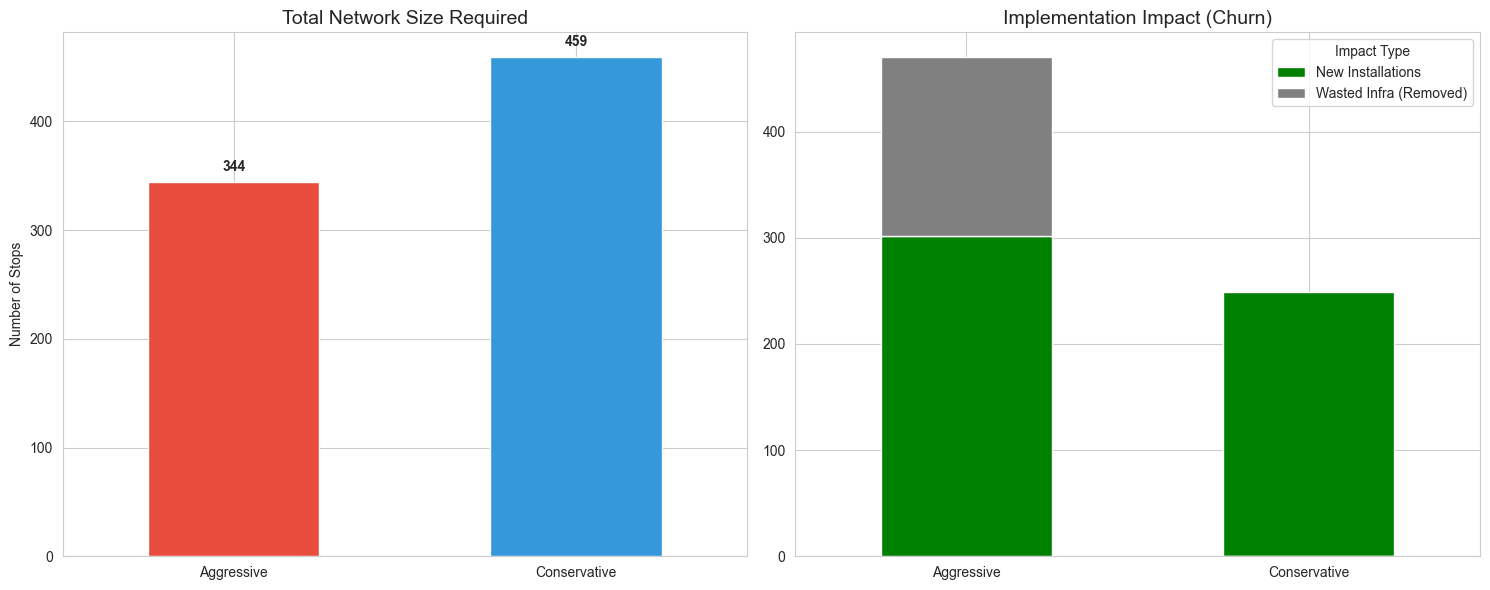

✓ Comparison charts saved.


In [25]:
def plot_comparison(agg_df, cons_df, total_stops):
    metrics = {
        'Aggressive': {
            'Total Stops': len(agg_df),
            'New Installations': len(agg_df[~agg_df['Code'].isin(df[df['HasSupport']]['Code'])]),
            'Wasted Infra (Removed)': len(df[df['HasSupport']]) - len(agg_df[agg_df['Code'].isin(df[df['HasSupport']]['Code'])])
        },
        'Conservative': {
            'Total Stops': len(cons_df),
            'New Installations': len(cons_df) - len(df[df['HasSupport']]),
            'Wasted Infra (Removed)': 0
        }
    }
    
    # Create DataFrame for plotting
    res_df = pd.DataFrame(metrics).T
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # 1. Total Stops Needed
    res_df['Total Stops'].plot(kind='bar', ax=axes[0], color=['#e74c3c', '#3498db'], rot=0)
    axes[0].set_title('Total Network Size Required', fontsize=14)
    axes[0].set_ylabel('Number of Stops')
    
    for i, v in enumerate(res_df['Total Stops']):
        axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')
        
    # 2. Cost/Churn Analysis
    res_df[['New Installations', 'Wasted Infra (Removed)']].plot(kind='bar', stacked=True, ax=axes[1], color=['green', 'gray'], rot=0)
    axes[1].set_title('Implementation Impact (Churn)', fontsize=14)
    axes[1].legend(title='Impact Type')
    
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['OUTPUT_DIR'], 'charts', 'strategy_comparison.png'))
    plt.show()
    
    # Save CSV metrics
    res_df.to_csv(os.path.join(CONFIG['OUTPUT_DIR'], 'data', 'comparison_metrics.csv'))
    print("✓ Comparison charts saved.")

plot_comparison(df_aggressive, df_conservative, len(df))

In [26]:
# 7. Map Generation
# Generates two separate maps for the strategies

def generate_map(target_df, title, filename):
    center_lat = df['Lat'].mean()
    center_lng = df['Lng'].mean()
    
    m = folium.Map(location=[center_lat, center_lng], zoom_start=12, tiles='CartoDB positron')
    
    # 1. Draw Coverage Circles
    for _, row in target_df.iterrows():
        folium.Circle(
            location=[row['Lat'], row['Lng']],
            radius=CONFIG['MAX_WALK_DIST'],
            color='#3498db',
            fill=True,
            fill_opacity=0.1,
            weight=0
        ).add_to(m)
        
    # 2. Draw Markers
    # Split into "Existing Retained" vs "New"
    existing_codes = set(df[df['HasSupport']]['Code'])
    
    for _, row in target_df.iterrows():
        is_existing = row['Code'] in existing_codes
        
        color = 'green' if is_existing else 'orange'
        status_text = "Existing Support" if is_existing else "New Installation"
        
        folium.CircleMarker(
            location=[row['Lat'], row['Lng']],
            radius=4,
            color=color,
            fill=True,
            fill_opacity=1,
            popup=f"<b>{row['Name']}</b><br>{status_text}<br>Code: {row['Code']}"
        ).add_to(m)
        
    # Add Legend
    legend_html = f'''
     <div style="position: fixed; bottom: 50px; right: 50px; width: 200px; height: 120px; 
     border:2px solid grey; z-index:9999; font-size:14px; background-color:white; padding: 10px;">
     <b>{title}</b><br>
     <i class="fa fa-circle" style="color:green"></i> Retained Support<br>
     <i class="fa fa-circle" style="color:orange"></i> New Installation<br>
     <i class="fa fa-circle" style="color:#3498db; opacity:0.5"></i> Coverage Area
     </div>
     '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    m.save(os.path.join(CONFIG['OUTPUT_DIR'], 'maps', filename))
    print(f"✓ Map saved: {filename}")

generate_map(df_aggressive, "Aggressive Strategy", "map_aggressive.html")
generate_map(df_conservative, "Conservative Strategy", "map_conservative.html")

✓ Map saved: map_aggressive.html
✓ Map saved: map_conservative.html


In [27]:
# 8. Export Results

# Save the full lists
df_aggressive.to_csv(os.path.join(CONFIG['OUTPUT_DIR'], 'data', 'aggressive_proposal.csv'), index=False)
df_conservative.to_csv(os.path.join(CONFIG['OUTPUT_DIR'], 'data', 'conservative_proposal.csv'), index=False)

print("\n=== Analysis Complete ===")
print(f"All files exported to: {CONFIG['OUTPUT_DIR']}/")


=== Analysis Complete ===
All files exported to: disability_support_analysis/


### Enhanced HTML Map Generation with Metrics
Export interactive maps with comprehensive coverage metrics and improvement statistics.

In [28]:
# Calculate detailed metrics for all scenarios

def calculate_metrics(supported_df, optimizer, scenario_name):
    """Calculate comprehensive coverage metrics for a given scenario."""
    coords = supported_df[['Lat', 'Lng']].values
    
    # Calculate coverage percentage
    coverage_pct = optimizer.calculate_coverage(coords) * 100
    
    # Calculate average distance to nearest supported stop for all stops
    total_stops = len(optimizer.df)
    distances = []
    covered_count = 0
    
    for i, (lat, lng) in enumerate(optimizer.coords):
        dists = optimizer.haversine_vectorized(lat, lng, coords[:,0], coords[:,1])
        min_dist = np.min(dists)
        distances.append(min_dist)
        if min_dist <= CONFIG['MAX_WALK_DIST']:
            covered_count += 1
    
    avg_distance = np.mean(distances)
    max_distance = np.max(distances)
    
    metrics = {
        'scenario': scenario_name,
        'supported_stops': len(supported_df),
        'total_stops': total_stops,
        'coverage_percentage': coverage_pct,
        'covered_stops': covered_count,
        'uncovered_stops': total_stops - covered_count,
        'avg_distance_m': avg_distance,
        'max_distance_m': max_distance,
        'within_500m': covered_count,
        'beyond_500m': total_stops - covered_count
    }
    
    return metrics

# Calculate metrics for all scenarios
current_supported = df[df['HasSupport']].copy()
metrics_before = calculate_metrics(current_supported, optimizer, 'BEFORE')
metrics_conservative = calculate_metrics(df_conservative, optimizer, 'Conservative')
metrics_aggressive = calculate_metrics(df_aggressive, optimizer, 'Aggressive')

print("\n=== Metrics Summary ===")
print(f"\nBEFORE (Current State):")
print(f"  Supported Stops: {metrics_before['supported_stops']}")
print(f"  Coverage: {metrics_before['coverage_percentage']:.2f}%")
print(f"  Avg Distance: {metrics_before['avg_distance_m']:.0f}m")

print(f"\nConservative Strategy:")
print(f"  Supported Stops: {metrics_conservative['supported_stops']}")
print(f"  Coverage: {metrics_conservative['coverage_percentage']:.2f}%")
print(f"  Improvement: +{metrics_conservative['coverage_percentage'] - metrics_before['coverage_percentage']:.2f}%")

print(f"\nAggressive Strategy:")
print(f"  Supported Stops: {metrics_aggressive['supported_stops']}")
print(f"  Coverage: {metrics_aggressive['coverage_percentage']:.2f}%")
print(f"  Improvement: +{metrics_aggressive['coverage_percentage'] - metrics_before['coverage_percentage']:.2f}%")


=== Metrics Summary ===

BEFORE (Current State):
  Supported Stops: 210
  Coverage: 28.89%
  Avg Distance: 1592m

Conservative Strategy:
  Supported Stops: 459
  Coverage: 91.53%
  Improvement: +62.64%

Aggressive Strategy:
  Supported Stops: 344
  Coverage: 90.12%
  Improvement: +61.24%


In [29]:
# Enhanced map generation with detailed metrics panels

def generate_enhanced_map(supported_df, metrics, title, filename, is_optimized=False, baseline_metrics=None):
    """Generate interactive map with comprehensive metrics display."""
    center_lat = df['Lat'].mean()
    center_lng = df['Lng'].mean()
    
    m = folium.Map(location=[center_lat, center_lng], zoom_start=12, tiles='CartoDB positron')
    
    # Determine colors based on scenario
    if is_optimized:
        circle_color = '#3498db'  # Blue for optimized
        marker_new_color = 'orange'
        marker_existing_color = 'green'
    else:
        circle_color = '#2ecc71'  # Green for current state
        marker_existing_color = '#2ecc71'
    
    # 1. Draw Coverage Circles
    for _, row in supported_df.iterrows():
        folium.Circle(
            location=[row['Lat'], row['Lng']],
            radius=CONFIG['MAX_WALK_DIST'],
            color=circle_color,
            fill=True,
            fill_opacity=0.1,
            weight=1,
            opacity=0.3
        ).add_to(m)
        
    # 2. Draw Markers
    existing_codes = set(df[df['HasSupport']]['Code'])
    
    for _, row in supported_df.iterrows():
        is_existing = row['Code'] in existing_codes
        
        if is_optimized:
            color = marker_existing_color if is_existing else marker_new_color
            status_text = "Existing Support" if is_existing else "New Installation"
        else:
            color = marker_existing_color
            status_text = "Current Support"
        
        folium.CircleMarker(
            location=[row['Lat'], row['Lng']],
            radius=5,
            color=color,
            fill=True,
            fill_opacity=0.8,
            weight=2,
            popup=f"<b>{row['Name']}</b><br>{status_text}<br>Code: {row['Code']}"
        ).add_to(m)
    
    # 3. Build metrics panel HTML
    scenario_color = '#e74c3c' if not is_optimized else ('#3498db' if 'Conservative' in title else '#9b59b6')
    
    # Header panel
    header_html = f'''
    <div style="position: fixed; 
                top: 10px; 
                left: 10px; 
                width: 350px; 
                background-color: white; 
                border: 3px solid {scenario_color}; 
                border-radius: 8px;
                padding: 15px;
                z-index: 9999;
                box-shadow: 2px 2px 6px rgba(0,0,0,0.3);">
        <h3 style="margin:0; color: {scenario_color};">{title}</h3>
        <p style="margin:5px 0; font-size:14px;">{metrics['supported_stops']} stops with support</p>
    </div>
    '''
    
    # Metrics panel
    metrics_html = f'''
    <div style="position: fixed; 
                top: 120px; 
                left: 10px; 
                width: 350px; 
                background-color: white; 
                border: 2px solid #ccc; 
                border-radius: 8px;
                padding: 15px;
                z-index: 9999;
                box-shadow: 2px 2px 6px rgba(0,0,0,0.3);">
        <h4 style="margin-top:0; margin-bottom:10px;">Coverage Metrics</h4>
    '''
    
    # Add legend items based on scenario
    if is_optimized:
        metrics_html += f'''
        <p style="margin: 5px 0;"><span style="color: {marker_existing_color}; font-size: 20px;">●</span> Retained support</p>
        <p style="margin: 5px 0;"><span style="color: {marker_new_color}; font-size: 20px;">●</span> New installation</p>
        '''
    else:
        metrics_html += f'''
        <p style="margin: 5px 0;"><span style="color: {marker_existing_color}; font-size: 20px;">●</span> Disability-supported stop</p>
        '''
    
    metrics_html += f'''
        <p style="margin: 5px 0;"><span style="color: {circle_color};">○</span> {CONFIG['MAX_WALK_DIST']}m walking radius</p>
        <hr style="margin: 10px 0;">
        <p style="margin: 5px 0; font-size: 12px;"><b>Coverage:</b> {metrics['coverage_percentage']:.1f}% within {CONFIG['MAX_WALK_DIST']}m</p>
        <p style="margin: 5px 0; font-size: 12px;"><b>Covered stops:</b> {metrics['covered_stops']:,} / {metrics['total_stops']:,}</p>
        <p style="margin: 5px 0; font-size: 12px;"><b>Avg distance:</b> {metrics['avg_distance_m']:.0f}m</p>
        <p style="margin: 5px 0; font-size: 12px;"><b>Max distance:</b> {metrics['max_distance_m']:.0f}m</p>
    '''
    
    # Add improvement metrics for optimized scenarios
    if is_optimized and baseline_metrics:
        improvement_pct = metrics['coverage_percentage'] - baseline_metrics['coverage_percentage']
        new_stops = metrics['supported_stops'] - baseline_metrics['supported_stops']
        improved_coverage = metrics['covered_stops'] - baseline_metrics['covered_stops']
        
        metrics_html += f'''
        <hr style="margin: 10px 0;">
        <h4 style="margin: 10px 0 5px 0; color: #27ae60;">Improvements</h4>
        <p style="margin: 5px 0; font-size: 12px;"><b>Coverage gain:</b> +{improvement_pct:.1f}%</p>
        <p style="margin: 5px 0; font-size: 12px;"><b>Additional stops:</b> +{new_stops}</p>
        <p style="margin: 5px 0; font-size: 12px;"><b>More stops covered:</b> +{improved_coverage:,}</p>
        <p style="margin: 5px 0; font-size: 12px;"><b>Distance reduction:</b> {baseline_metrics['avg_distance_m'] - metrics['avg_distance_m']:.0f}m avg</p>
        '''
    
    metrics_html += '</div>'
    
    # Add both panels to map
    m.get_root().html.add_child(folium.Element(header_html))
    m.get_root().html.add_child(folium.Element(metrics_html))
    
    # Save map
    output_path = os.path.join(CONFIG['OUTPUT_DIR'], 'maps', filename)
    m.save(output_path)
    print(f"✓ Enhanced map saved: {filename}")
    
    return output_path

# Generate all three maps with metrics
print("\n=== Generating Enhanced HTML Maps ===")

map_before = generate_enhanced_map(
    current_supported, 
    metrics_before, 
    "BEFORE: Current Disability Support",
    "disability_support_BEFORE_optimization.html",
    is_optimized=False
)

map_conservative = generate_enhanced_map(
    df_conservative,
    metrics_conservative,
    "AFTER: Conservative Strategy",
    "disability_support_CONSERVATIVE_optimized.html",
    is_optimized=True,
    baseline_metrics=metrics_before
)

map_aggressive = generate_enhanced_map(
    df_aggressive,
    metrics_aggressive,
    "AFTER: Aggressive Strategy", 
    "disability_support_AGGRESSIVE_optimized.html",
    is_optimized=True,
    baseline_metrics=metrics_before
)

print("\n✓ All enhanced maps generated successfully!")


=== Generating Enhanced HTML Maps ===
✓ Enhanced map saved: disability_support_BEFORE_optimization.html
✓ Enhanced map saved: disability_support_CONSERVATIVE_optimized.html
✓ Enhanced map saved: disability_support_AGGRESSIVE_optimized.html

✓ All enhanced maps generated successfully!


In [30]:
# Export comprehensive metrics summary

metrics_summary = pd.DataFrame([
    metrics_before,
    metrics_conservative,
    metrics_aggressive
])

metrics_summary['improvement_percentage'] = metrics_summary['coverage_percentage'] - metrics_before['coverage_percentage']
metrics_summary['additional_stops'] = metrics_summary['supported_stops'] - metrics_before['supported_stops']
metrics_summary['distance_reduction_m'] = metrics_before['avg_distance_m'] - metrics_summary['avg_distance_m']

# Save to CSV
metrics_path = os.path.join(CONFIG['OUTPUT_DIR'], 'data', 'metrics_summary.csv')
metrics_summary.to_csv(metrics_path, index=False)

print("\n=== Metrics Summary ===")
print(metrics_summary[['scenario', 'supported_stops', 'coverage_percentage', 'improvement_percentage', 'additional_stops', 'avg_distance_m']].to_string(index=False))
print(f"\n✓ Metrics saved to: {metrics_path}")


=== Metrics Summary ===
    scenario  supported_stops  coverage_percentage  improvement_percentage  additional_stops  avg_distance_m
      BEFORE              210            28.885768                0.000000                 0     1591.819035
Conservative              459            91.526217               62.640449               249      234.676241
  Aggressive              344            90.121723               61.235955               134      249.270832

✓ Metrics saved to: disability_support_analysis\data\metrics_summary.csv
